### This notebook does a few sanity checks on Mike's new coarsened GC data, comparing it to the original hourly data

In [1]:
import pdb
import glob
import numpy as np
import xarray as xr
import inversion_tools
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
%matplotlib inline

loc     = '/work/noaa/co2/aschuh/WOMBAT_stuff/wombat-v3-forward'
new_dir = '4a_postprocessing_gc/intermediates/daily'
old_dir = '3a_transport_gc/intermediates/runs'
pdir    = '/work/noaa/co2/jhollo/processed_transport_data/old_new_data_comparisons'

In [18]:
def read_data(source, component, region, kind='mf', level=None, resample=None, year=2016, month=1, pft=9, overwrite=False):
    print(f'-------- working on {source} --------')
    print(f'---- working on component={component}')

    if(component == 'residual'):
        sfx  = f'_month{year}-{month:02d}'
        fsfx =''
    else:
        sfx  = ''
        fsfx = f'{year}'
        climo_comp = component.replace("12_", "", 1)
        
    if(source in ['bio_gpp', 'bio_resp_tot']):
        new_component = f'{component}_pft{pft:02d}'
        s  = source.strip('bio_').strip('_tot')
    else: 
        new_component = component
        s = source

    if(kind=='mf'):
        kindstr = 'daily-mole-fraction'
    elif(kind=='flux'):
        kindstr = 'daily-fluxes'
    else:
        raise RuntimeError(f'kind must be \'mf\' or \'flux\', not {kind}')

    if(kind=='flux' and level is not None):
        raise RuntimeError('\'level\' must be None when kind=\'flux\'')

    # get 1 year of evolution
    new_files = sorted(glob.glob(f'{loc}/{new_dir}/{source}_{new_component}_regionRegion{region:02d}{sfx}/{kindstr}*{fsfx}.nc4'))
    new_data  = xr.open_dataset(new_files[0])
    if(kind=='mf'):
        new_data  = new_data.isel(lev=level-1)
    if(kind=='flux'):
        new_data = new_data * 86400 / 1e3 # convert to g m2/day from kg m2/s??

    # make filename
    if(resample is not None): rs = f'_resample-{resample}'
    else:                     rs = ''
    if(kind == 'flux'):
        fname = f'{pdir}/{source}_{component}_flux_{year}-{month:02d}_pft{pft:02d}_region{region:02d}{rs}_lev{level}.nc'
    else:
        fname = f'{pdir}/{source}_{component}_{year}-{month:02d}_pft{pft:02d}_region{region:02d}{rs}_lev{level}.nc'

    # read the data
    if(component == 'residual'):
        try:
            if(overwrite): raise FileNotFoundError
            old_data = xr.open_dataset(fname)
            print('read old data from file...')
        except FileNotFoundError:
            mm  = f'{year}-{month:02d}'
            sd  = f'{year}-{month:02d}-01'
            ed  = f'{int(year)+1}-{month:02d}-01'
            rf  = [True, False][kind == 'mf']
            rmf = not rf
            old_data = inversion_tools.v1.read_transport_jacobians_residual(s, sd, ed, region=int(region), month=mm, pft=int(pft), 
                                                                            lev=level, rechunk=False, quiet=False, resample=resample,
                                                                            return_flux=rf, return_mf=rmf)
            print('writing out...')
            old_data.to_netcdf(fname)
            
    else:
        try:
            if(overwrite): raise FileNotFoundError
            old_data = xr.open_dataset(fname)
            print('read old data from file...')
        except FileNotFoundError:
            sd  = f'{year}-{month:02d}-01'
            ed  = f'{int(year)+1}-{month:02d}-01'
            rf  = [True, False][kind == 'mf']
            rmf = not rf
            old_data = inversion_tools.v1.read_transport_jacobians_climo(s, sd, ed, region=int(region), pft=int(pft), 
                                                                         lev=level, rechunk=False, quiet=False, resample=resample, 
                                                                         component=climo_comp,
                                                                         return_flux=rf, return_mf=rmf)
            print('writing out...')
            old_data.to_netcdf(fname)

    return old_data, new_data

In [62]:
def plot_data(source, component, region, year=2016, month=1, kind='mf', 
              lat=45, lev=None, lon=None, resample=None, ylim=None, xlim=None, 
              ax=None, overwrite=False, loc='best', old_kw={}, new_kw={}):
    '''
    Plots a 1D timeseries of the mole fraction data for a specified location and averaging

    Parameters
    ----------
    lat : float
        the latitude to select
    lev : int
        the level to select, by index
    lon : float, optional
        the longitude to select. Deafults to None, in which case a zonal mean
        is taken across longitude
    resample : bool, optional
        temporal resampling of the old data. Defaults to None, in which case
        the native 3-hourly data is used.
    '''

    if(kind=='mf'):     
        var  = 'mole_fraction'
        unit = 'ppm'
    elif(kind=='flux'): 
        var  = 'flux'
        unit = 'g m2/day'

    if(kind=='flux' and lev is not None):
        raise RuntimeError('\'lev\' must be None when kind=\'flux\'')

    if(component == 'seasonal'):
        components = ['sin12_1', 'sin12_2', 'cos12_1', 'cos12_2', 'sin12_3', 'cos12_3']
        if(source == 'ocean'): components = components[0:4]
        for i in range(len(components)):
            comp0 = components[0].replace('12_','',1)
            compi = components[i].replace('12_','',1)
            oldi, newi = read_data(source, components[i], region, kind, lev, resample, overwrite=overwrite)
            if(i==0): 
                old, new = oldi, newi
            else:
                old[comp0] = old[comp0] + oldi[compi].values
                new[var] = new[var] + newi[var].values
        old_data = old[comp0]
        new_data = new[var]
    else:
        old, new = read_data(source, component, region, kind, lev, resample, overwrite=overwrite)
        old_data = old[component.replace('12_','',1)]
        new_data = new[var]
    
    latc = ['N', 'S'][lat<0]
    if(lat==0): latc = ''

    if(lev is not None):
        plev = inversion_tools.lev_to_p(lev)
        levstr = ', level {plev} hPa'
    else:
        levstr = ''

    if(lon is None):
        old_zm  = old_data.mean('lon').sel(lat=lat, method='nearest')
        new_zm  = (new_data.mean('lon').sel(lat=lat, method='nearest') * 1e6)
        label = 'zonal mean at'
    else:
        old_zm  = old_data.sel(lon=lon, lat=lat, method='nearest')
        new_zm  = (new_data.sel(lon=lon, lat=lat, method='nearest') * 1e6)
        label   = f'grided data at lon={lon}°,'

    if(resample == '1D'):
        resample_str = ' (daily averaged)'
    else:
        resample_str = ''
        
    if(ax is None):
        fig = plt.figure()
        ax  = fig.add_subplot()
    ax.plot(old_zm.time, old_zm, label=f'3-hourly data{resample_str}', **old_kw)
    ax.plot(new_zm.time, new_zm, label='processed daily data', **new_kw)
    ax.set_title(f'{source} {component}, region {region}, {year}-{month}\n{label} {lat}°{latc}{levstr}')
    ax.set_ylabel(f'{source} {component} [{unit}]')
    ax.legend(loc=loc)
    ax.grid(alpha=0.2)
    #ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    ax.tick_params(axis="x", labelrotation=20)
    if(ylim is not None):
        ax.set_ylim(ylim)
    if(xlim is not None):
        ax.set_xlim(xlim)

    return old_zm, new_zm
    

### Let's first check the daily fluxes

-------- working on bio_resp_tot --------
---- working on component=intercept
read old data from file...
-------- working on bio_resp_tot --------
---- working on component=trend
read old data from file...
-------- working on bio_resp_tot --------
---- working on component=sin12_1
read old data from file...
-------- working on bio_resp_tot --------
---- working on component=sin12_2
read old data from file...
-------- working on bio_resp_tot --------
---- working on component=cos12_1
read old data from file...
-------- working on bio_resp_tot --------
---- working on component=cos12_2
read old data from file...
-------- working on bio_resp_tot --------
---- working on component=sin12_3
read old data from file...
-------- working on bio_resp_tot --------
---- working on component=cos12_3
read old data from file...
-------- working on bio_resp_tot --------
---- working on component=residual
read old data from file...


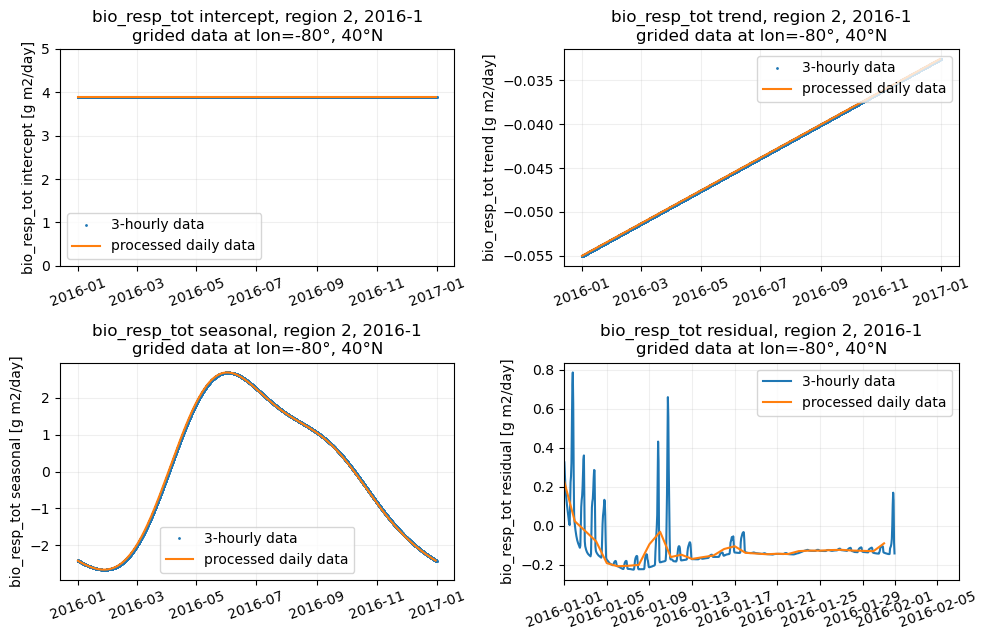

In [76]:
fig, ax = plt.subplots(2,2, figsize=(10,6.5))
old_kw={'marker':'.','lw':0, 'ms':2}
#old_kw={}

old, new = plot_data('bio_resp_tot', 'intercept', 2, 2016, 1, 'flux', 40, None, -80, ax=ax[0][0], ylim=[0, 5],  old_kw=old_kw)
plot_data('bio_resp_tot', 'trend', 2, 2016, 1, 'flux', 40, None, -80, ax=ax[0][1], loc='upper right', old_kw=old_kw)
plot_data('bio_resp_tot', 'seasonal', 2, 2016, 1, 'flux', 40, None, -80, ax=ax[1][0], old_kw=old_kw)
plot_data('bio_resp_tot', 'residual', 2, 2016, 1, 'flux', 40, None, -80, ax=ax[1][1], xlim=[np.datetime64('2016-01'), np.datetime64('2016-02-07')])
plt.tight_layout()
plt.savefig('verification_figs/resp_flux.png', dpi=200)

-------- working on bio_gpp --------
---- working on component=intercept
read old data from file...
-------- working on bio_gpp --------
---- working on component=trend
read old data from file...
-------- working on bio_gpp --------
---- working on component=sin12_1
read old data from file...
-------- working on bio_gpp --------
---- working on component=sin12_2
read old data from file...
-------- working on bio_gpp --------
---- working on component=cos12_1
read old data from file...
-------- working on bio_gpp --------
---- working on component=cos12_2
read old data from file...
-------- working on bio_gpp --------
---- working on component=sin12_3
read old data from file...
-------- working on bio_gpp --------
---- working on component=cos12_3
read old data from file...
-------- working on bio_gpp --------
---- working on component=residual
read old data from file...


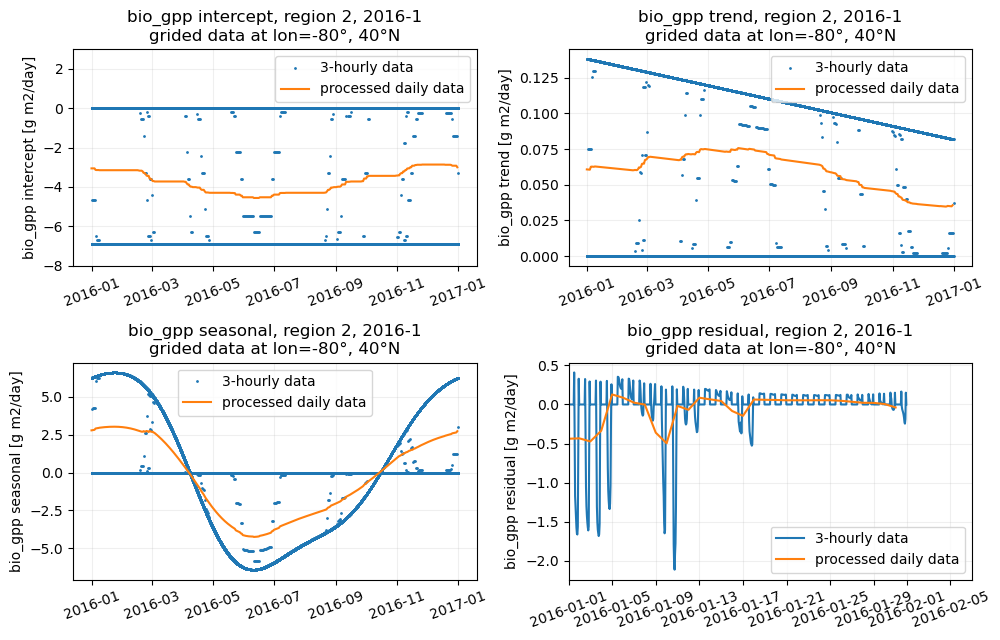

In [68]:
fig, ax = plt.subplots(2,2, figsize=(10,6.5))
old_kw={'marker':'.','lw':0, 'ms':2}
#old_kw={}

old, new = plot_data('bio_gpp', 'intercept', 2, 2016, 1, 'flux', 40, None, -80, ax=ax[0][0], ylim=[-8, 3], loc='upper right', old_kw=old_kw)
plot_data('bio_gpp', 'trend', 2, 2016, 1, 'flux', 40, None, -80, ax=ax[0][1], loc='upper right', old_kw=old_kw)
plot_data('bio_gpp', 'seasonal', 2, 2016, 1, 'flux', 40, None, -80, ax=ax[1][0], old_kw=old_kw)
plot_data('bio_gpp', 'residual', 2, 2016, 1, 'flux', 40, None, -80, ax=ax[1][1], xlim=[np.datetime64('2016-01'), np.datetime64('2016-02-07')])
plt.tight_layout()
plt.savefig('verification_figs/gpp_flux.png', dpi=200)

-------- working on ocean --------
---- working on component=intercept
read old data from file...
-------- working on ocean --------
---- working on component=trend
read old data from file...
-------- working on ocean --------
---- working on component=sin12_1
read old data from file...
-------- working on ocean --------
---- working on component=sin12_2
read old data from file...
-------- working on ocean --------
---- working on component=cos12_1
read old data from file...
-------- working on ocean --------
---- working on component=cos12_2
read old data from file...
-------- working on ocean --------
---- working on component=residual
read old data from file...


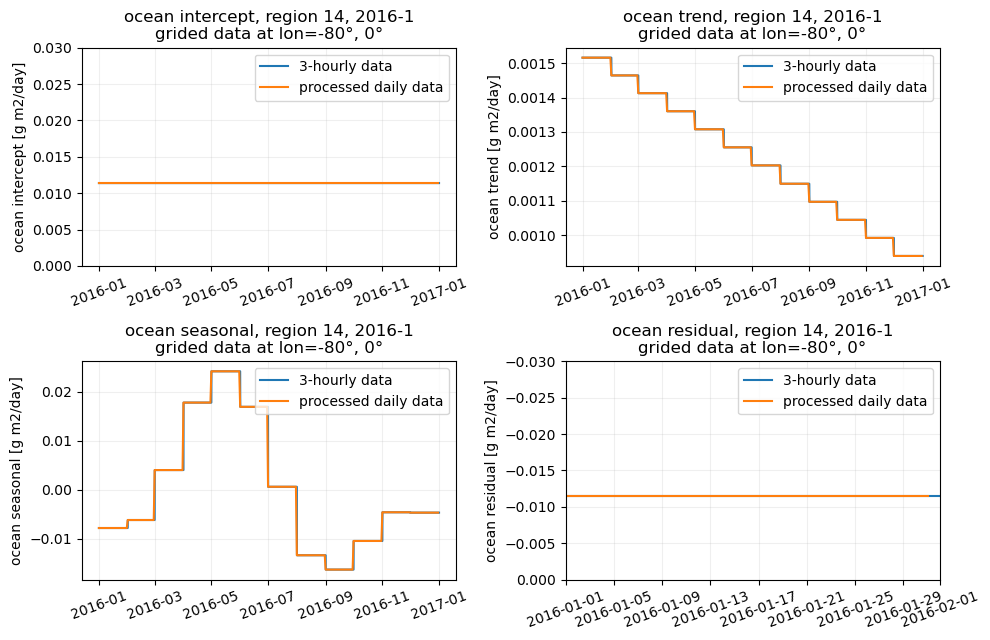

In [70]:
fig, ax = plt.subplots(2,2, figsize=(10,6.5))
plot_data('ocean', 'intercept', 14, 2016, 1, 'flux', 0, None, -80, ax=ax[0][0], ylim=[0, 0.03])
plot_data('ocean', 'trend', 14, 2016, 1, 'flux', 0, None, -80, ax=ax[0][1])
plot_data('ocean', 'seasonal', 14, 2016, 1, 'flux', 0, None, -80, ax=ax[1][0])
plot_data('ocean', 'residual', 14, 2016, 1, 'flux', 0, None, -80, ax=ax[1][1], xlim=[np.datetime64('2016-01'), np.datetime64('2016-02')], ylim=[0,-0.03])
plt.tight_layout()
plt.savefig('verification_figs/ocean_flux.png', dpi=200)

### Now to also check the daily mole fractions

-------- working on bio_gpp --------
---- working on component=intercept
read old data from file...
-------- working on bio_gpp --------
---- working on component=trend
read old data from file...
-------- working on bio_gpp --------
---- working on component=sin12_1
read old data from file...
-------- working on bio_gpp --------
---- working on component=sin12_2
read old data from file...
-------- working on bio_gpp --------
---- working on component=cos12_1
read old data from file...
-------- working on bio_gpp --------
---- working on component=cos12_2
read old data from file...
-------- working on bio_gpp --------
---- working on component=sin12_3
read old data from file...
-------- working on bio_gpp --------
---- working on component=cos12_3
read old data from file...
-------- working on bio_gpp --------
---- working on component=residual
read old data from file...


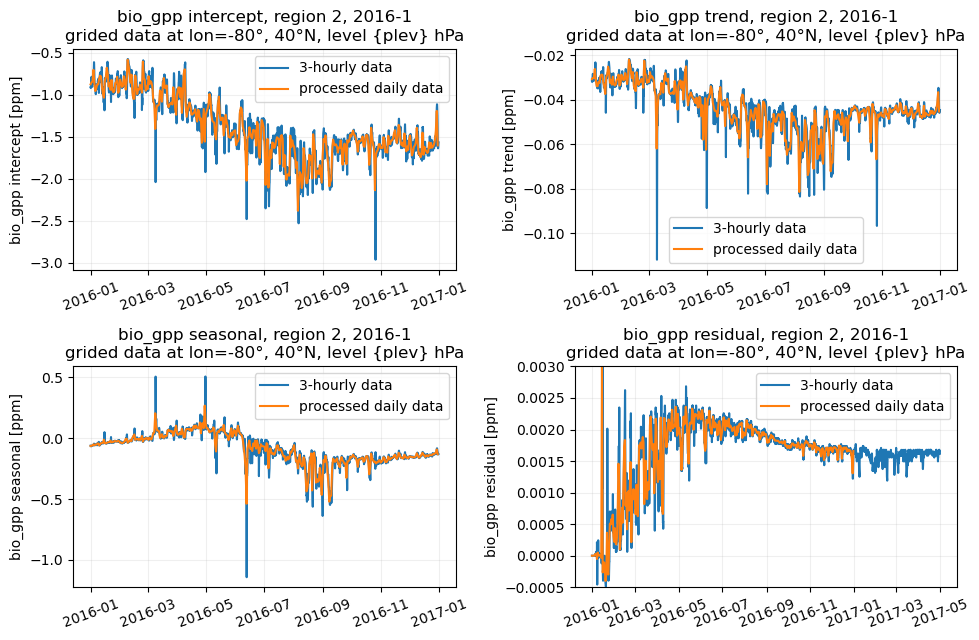

In [71]:
fig, ax = plt.subplots(2,2, figsize=(10,6.5))
plot_data('bio_gpp', 'intercept', 2, 2016, 1, 'mf', 40, 30, -80, ax=ax[0][0])
plot_data('bio_gpp', 'trend',     2, 2016, 1, 'mf', 40, 30, -80, ax=ax[0][1])
plot_data('bio_gpp', 'seasonal',  2, 2016, 1, 'mf', 40, 30, -80, ax=ax[1][0])
plot_data('bio_gpp', 'residual',  2, 2016, 1, 'mf', 40, 30, -80, ylim=[-0.0005, 0.003], ax=ax[1][1])
plt.tight_layout()
plt.savefig('verification_figs/gpp.png', dpi=200)

-------- working on ocean --------
---- working on component=intercept
read old data from file...
-------- working on ocean --------
---- working on component=trend
read old data from file...
-------- working on ocean --------
---- working on component=sin12_1
read old data from file...
-------- working on ocean --------
---- working on component=sin12_2
read old data from file...
-------- working on ocean --------
---- working on component=cos12_1
read old data from file...
-------- working on ocean --------
---- working on component=cos12_2
read old data from file...
-------- working on ocean --------
---- working on component=residual
read old data from file...


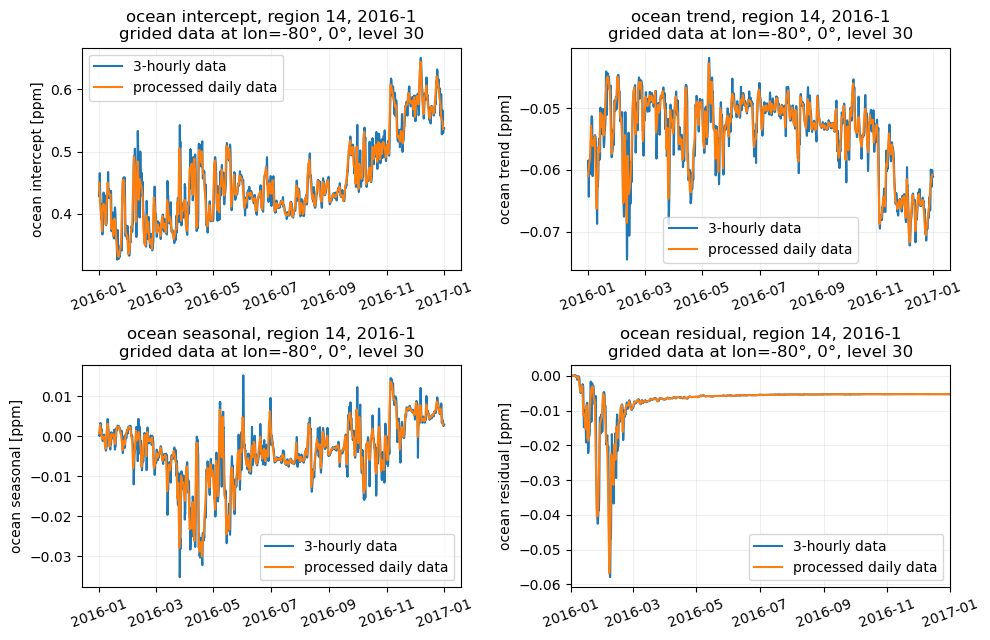

In [8]:
fig, ax = plt.subplots(2,2, figsize=(10,6.5))
plot_data('ocean', 'intercept', 14, 2016, 1, 'mf', 0, 30, -80, ax=ax[0][0])
plot_data('ocean', 'trend',     14, 2016, 1, 'mf', 0, 30, -80, ax=ax[0][1])
plot_data('ocean', 'seasonal',  14, 2016, 1, 'mf', 0, 30, -80, ax=ax[1][0])
plot_data('ocean', 'residual',  14, 2016, 1, 'mf', 0, 30, -80, ax=ax[1][1])
plt.tight_layout()
plt.savefig('verification_figs/ocean.png', dpi=200)

-------- working on bio_resp_tot --------
---- working on component=intercept
read old data from file...
-------- working on bio_resp_tot --------
---- working on component=trend
read old data from file...
-------- working on bio_resp_tot --------
---- working on component=sin12_1
read old data from file...
-------- working on bio_resp_tot --------
---- working on component=sin12_2
read old data from file...
-------- working on bio_resp_tot --------
---- working on component=cos12_1
read old data from file...
-------- working on bio_resp_tot --------
---- working on component=cos12_2
read old data from file...
-------- working on bio_resp_tot --------
---- working on component=sin12_3
read old data from file...
-------- working on bio_resp_tot --------
---- working on component=cos12_3
read old data from file...
-------- working on bio_resp_tot --------
---- working on component=residual
read old data from file...


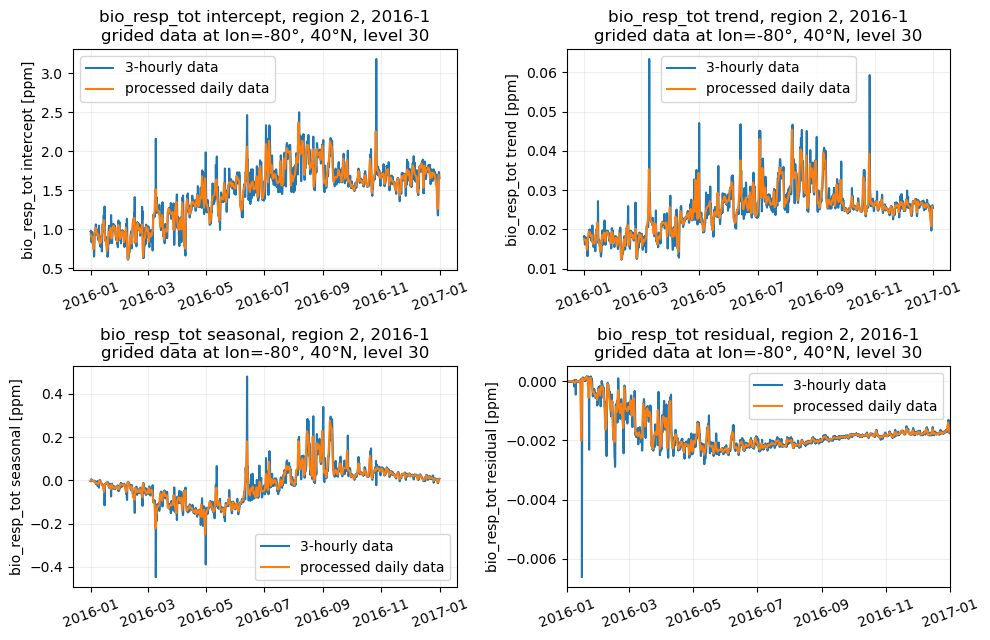

In [10]:
fig, ax = plt.subplots(2,2, figsize=(10,6.5))
plot_data('bio_resp_tot', 'intercept', 2, 2016, 1, 'mf', 40, 30, -80, ax=ax[0][0])
plot_data('bio_resp_tot', 'trend',     2, 2016, 1, 'mf', 40, 30, -80, ax=ax[0][1])
plot_data('bio_resp_tot', 'seasonal',  2, 2016, 1, 'mf', 40, 30, -80, ax=ax[1][0])
plot_data('bio_resp_tot', 'residual',  2, 2016, 1, 'mf', 40, 30, -80, ax=ax[1][1])
plt.tight_layout()
plt.savefig('verification_figs/resp.png', dpi=200)

### Old code for debugging purposes which have now been resolved (explanation for disagreement was that I was subtracting a uniform 400ppm rather than subtracting the bcakground 400ppm runs)

In [6]:
# lets try this fully manually to rule out anything my old code might be doing wrong...
# the mapping line is
# "bio_gpp_residual_pft09_regionRegion02_month2016-01","residual_20160101_part003","r0018p003s001"

forward_dir      = f'/work/noaa/co2/aschuh/WOMBAT_stuff/wombat-v3-forward'
gc_transport_dir = f'{forward_dir}/3a_transport_gc/intermediates/runs'
data_dir         = f'{gc_transport_dir}/residual_20160101_part003'

data_files = []
for i in range(3):
    data_files.extend(sorted(glob.glob(f'{data_dir}_split{i+1:02d}/OutputDir/GEOSChem.SpeciesConcThreeHourly.*.nc4')))

data = [0]*len(data_files)
for i in range(len(data)):
    if(i%10 == 0):
        print(f'reading file {i+1}/{len(data)}', end='\r')
    data[i] = xr.open_dataset(data_files[i])[f'SpeciesConcVV_r0018p003s001'].isel(lev=29)
datac = xr.concat(data, dim='time')

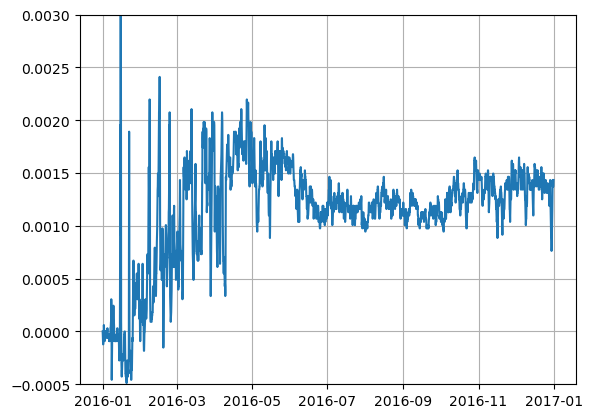

In [11]:
dd = datac.sel(lat=40, lon=-80, method='nearest') * 1e6 - 400
plt.plot(dd.time, dd)
plt.ylim([-0.0005, 0.003])
plt.grid()

In [12]:
dd_daily = []
for i in range(int(len(dd.time)/8)):
    dd_daily.append((dd[i*8]+dd[i*8+1]+dd[i*8+2]+dd[i*8+3]+\
                     dd[i*8+4]+dd[i*8+5]+dd[i*8+6]+dd[i*8+7])/8)

-------- working on bio_gpp --------
---- working on component=residual
read old data from file...


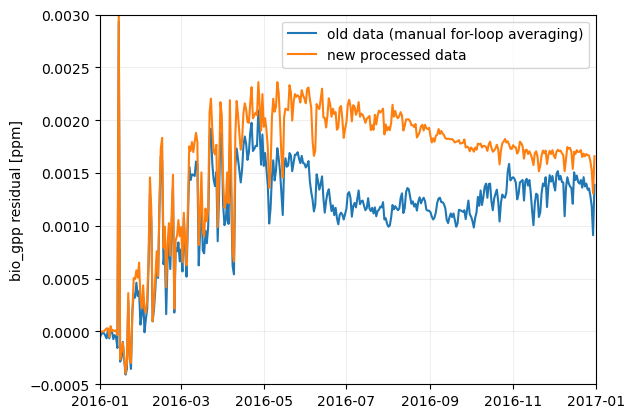

In [20]:
old, new = read_data('bio_gpp', 'residual', 30, '1D')
newd = new['mole_fraction'].sel(lat=40, lon=-80, method='nearest')*1e6
plt.plot(dd.time.values[::8], dd_daily, label='old data (manual for-loop averaging)')
plt.plot(newd.time, newd, label='new processed data')
plt.ylim([-0.0005, 0.003])
plt.grid(alpha=0.2)
plt.ylabel('bio_gpp residual [ppm]')
plt.gca().set_xlim([np.datetime64('2016-01'), np.datetime64('2017-01')])
plt.legend()